# Black-Box Optimization [![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maxencefaldor/bbobax/blob/main/notebooks/02_bbo.ipynb)

In this notebook, we optimize one BBOB problem with an evolution strategy, end to end: sample an instance, run the ask-evaluate-tell loop under `jax.lax.scan`, and read the result as the benchmark reads it -- best-so-far *precision* $f_\mathrm{best} - f_\mathrm{opt}$, in log scale.

This inner loop is the unit everything later is built from: [03_benchmarking](03_benchmarking.ipynb) runs it for several algorithms across the whole suite, and [04_meta_bbo](04_meta_bbo.ipynb) wraps it in a meta-optimization.

## Install

You will need Python 3.11 or later, and a working JAX installation. For example, you can install JAX with:

In [ ]:
%pip install -U "jax[cuda]"

Then, install bbobax from PyPi:

In [ ]:
%pip install -U "bbobax[notebooks]"

## Import

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from evosax.algorithms import CMA_ES

from bbobax import SchaffersF7

In [2]:
seed = 0

key = jax.random.key(seed)

## The problem

Schaffers F7 at $D = 2$ -- multimodal enough to be interesting. Instance generation is left at COCO's defaults: the optimum lands somewhere in $[-4, 4]^2$ with a random rotation, so the optimizer cannot rely on any particular placement.

In [3]:
problem = SchaffersF7(num_dims=2)

key, subkey = jax.random.split(key)
params = problem.sample(subkey)

## The optimizer

CMA-ES from evosax, at its published defaults, initialized at a uniformly drawn point of the box -- the same initialization any BBOB experiment uses.

In [4]:
population_size = 128

es = CMA_ES(population_size=population_size, solution=jnp.zeros(problem.num_dims))
es_params = es.default_params

key, key_mean, key_init = jax.random.split(key, 3)
es_state = es.init(key_init, problem.sample_x(key_mean), es_params)

## The ask-evaluate-tell loop

One generation is: `ask` for a population, evaluate it (vmapped, one key per solution -- for a noisy problem this is where the noise would enter), `tell` the fitnesses back. `jax.lax.scan` compiles the whole run into a single program, and carries out the best fitness of every generation.

In [5]:
def step(es_state, key):
    """One generation of ask, evaluate, tell."""
    key_ask, key_eval, key_tell = jax.random.split(key, 3)

    population, es_state = es.ask(key_ask, es_state, es_params)
    keys = jax.random.split(key_eval, population_size)
    fitness = jax.vmap(problem.evaluate, in_axes=(0, 0, None))(
        keys, population, params
    ).fitness
    es_state, _ = es.tell(key_tell, population, fitness, es_state, es_params)

    return es_state, jnp.min(fitness)


num_generations = 64

key, subkey = jax.random.split(key)
_, best = jax.lax.scan(step, es_state, jax.random.split(subkey, num_generations))

## The result

Best-so-far precision, in log scale. The dashed line is $10^{-8}$, COCO's hardest target: below it, BBOB considers the problem solved.

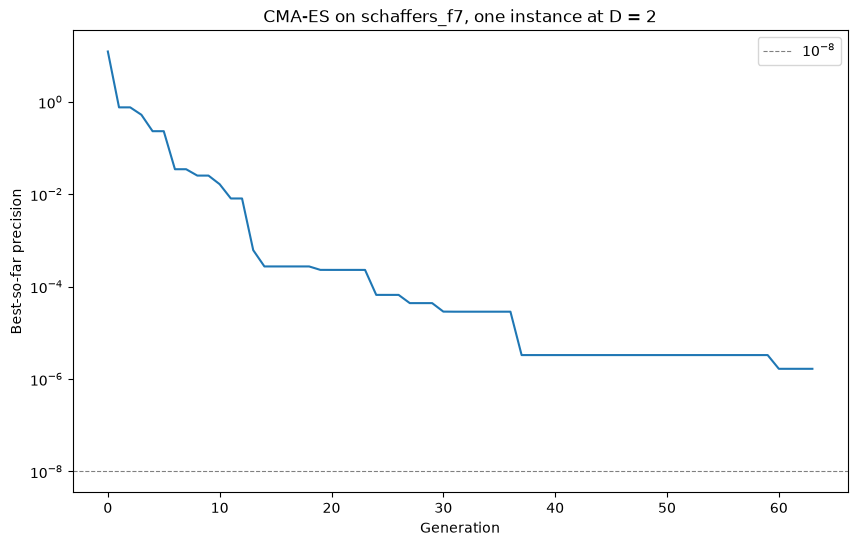

In [6]:
precision = jax.lax.cummin(best) - params.f_opt

plt.figure(figsize=(10, 6))
plt.plot(precision)
plt.axhline(1e-8, color="gray", linestyle="--", linewidth=0.8, label="$10^{-8}$")
plt.yscale("log")
plt.xlabel("Generation")
plt.ylabel("Best-so-far precision")
plt.title(f"CMA-ES on {problem.name}, one instance at D = {problem.num_dims}")
plt.legend()
plt.show()

## Next

- [03_benchmarking](03_benchmarking.ipynb) -- this loop, for six algorithms across the whole suite.
- [04_meta_bbo](04_meta_bbo.ipynb) -- this loop as the inner level of a meta-optimization.